--- 5 Data Teratas ---
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

--- Distribusi Target (Potability) ---
Potability
0    1998
1    1278
Name: count, dtype: int64


/tmp/ipykernel_1004/571713650.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Potability', data=df, palette='Set2')


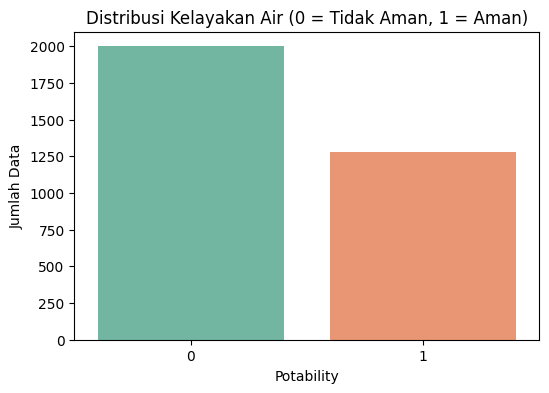

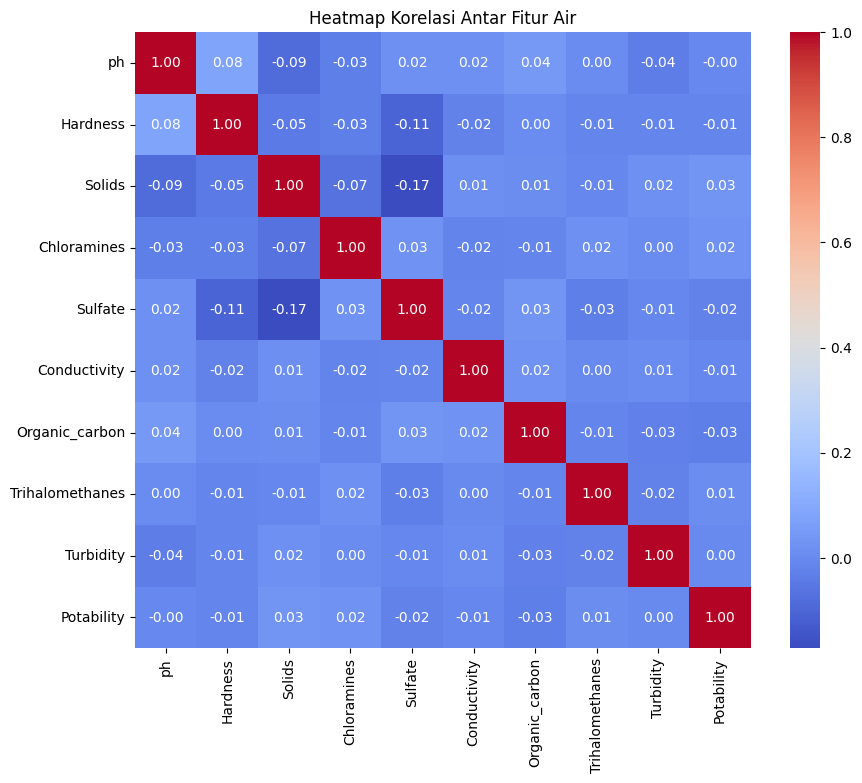

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('water_potability.csv')

print("--- 5 Data Teratas ---")
print(df.head())

print("\n--- Distribusi Target (Potability) ---")
print(df['Potability'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Potability', data=df, palette='Set2')
plt.title('Distribusi Kelayakan Air (0 = Tidak Aman, 1 = Aman)')
plt.xlabel('Potability')
plt.ylabel('Jumlah Data')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Heatmap Korelasi Antar Fitur Air')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('water_potability.csv')

df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].mean())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean())

print("Pengecekan Null Value setelah dibersihkan:")
print(df.isnull().sum())

X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData Preparation Selesai!")
print(f"Jumlah data latih: {X_train_scaled.shape[0]}")
print(f"Jumlah data uji: {X_test_scaled.shape[0]}")

Pengecekan Null Value setelah dibersihkan:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Data Preparation Selesai!
Jumlah data latih: 2620
Jumlah data uji: 656


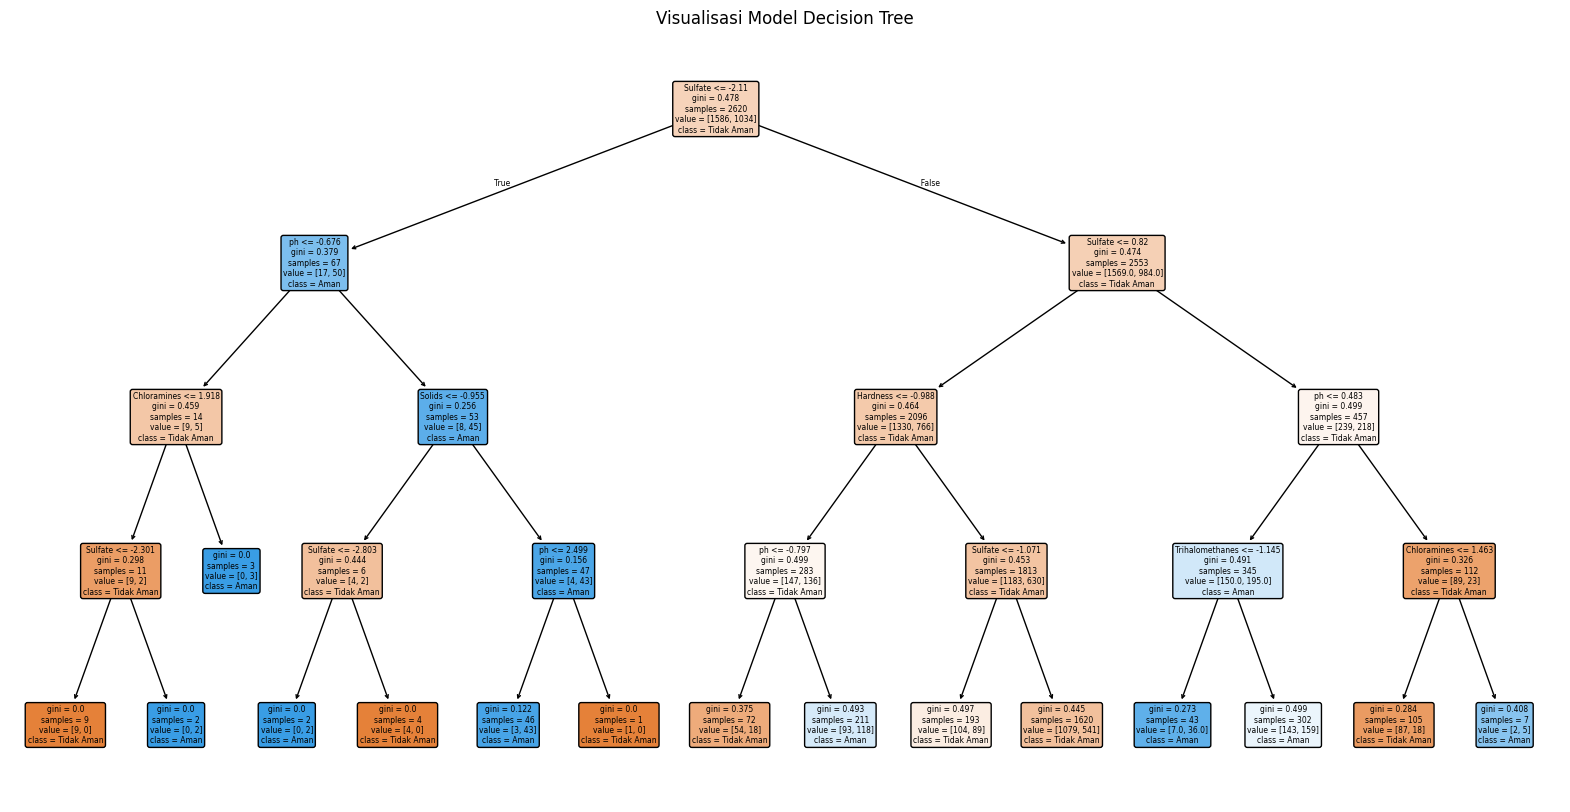


--- Evaluasi Kinerja: Decision Tree ---
Accuracy: 0.6326

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.67      0.83      0.74       412
           1       0.51      0.31      0.38       244

    accuracy                           0.63       656
   macro avg       0.59      0.57      0.56       656
weighted avg       0.61      0.63      0.61       656



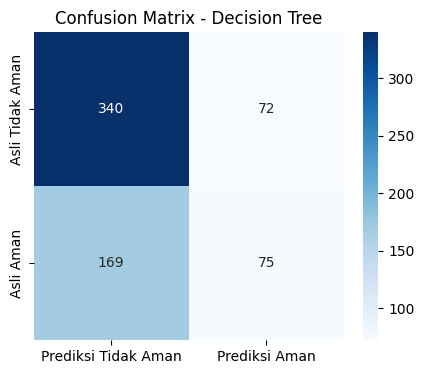


--- Evaluasi Kinerja: K-Nearest Neighbors (KNN) ---
Accuracy: 0.6280

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.69      0.75      0.72       412
           1       0.50      0.42      0.46       244

    accuracy                           0.63       656
   macro avg       0.59      0.59      0.59       656
weighted avg       0.62      0.63      0.62       656



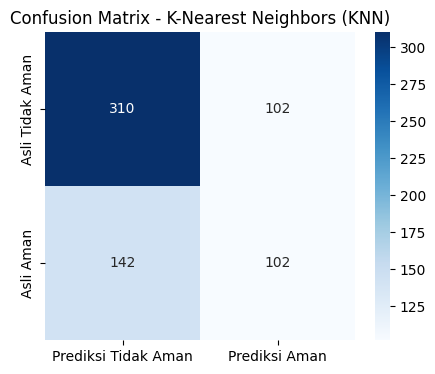

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

dt_model.fit(X_train_scaled, y_train)
knn_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Tidak Aman', 'Aman'], filled=True, rounded=True)
plt.title("Visualisasi Model Decision Tree")
plt.show()

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- Evaluasi Kinerja: {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nClassification Report (Precision, Recall, F1-Score):")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Prediksi Tidak Aman', 'Prediksi Aman'],
                yticklabels=['Asli Tidak Aman', 'Asli Aman'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)")